You've built an LLM judge (to grade code review comments, agent traces, essay
feedback, whatever). Before trusting it, you decide to do the responsible thing and hand-label
a smaller, random sample. You compute inter-rater reliability (IRR) between your scores and the judge's.

The number comes back awesome. Quadratic-weighted Cohen's κ of 0.75, comfortably
"substantial agreement" by common standards. Surely that licenses
running statistics directly on the judge's scores from here on?

**No.** For several of the IRR metrics researchers reach for most, the
false-positive rate of a test run on raw judge scores doesn't fall as
agreement rises. In fact, counter-intuitively, it peaks right around where the judge looks most
trustworthy:

<img src="../media/irr-alignment-fpr-panels.png" alt="Five panels showing false-positive rate against LLM judge-human alignment for different IRR metrics. On Likert data (kappa, ICC, weighted kappa) false-positive rate peaks around 0.80-0.90 agreement, the 'almost perfect' range, and only returns to nominal 5% above 0.99. On continuous data false-positive rate rises with Pearson's r. A PPI-corrected test stays flat at nominal 5% throughout." style="max-width: 900px; width: 100%" />

That Cohen's κ that delighted you is actually a huge warning sign---because whoops, it turns out that this is the regime where it is _most_ dangerous to trust the results, not least. 
Our simulations show this: plotting the judge-human alignment (x-axis) against the false-positive
rate of a naive test run on the judge's raw scores directly, shows how many IRR metrics behave as alignment increases. On Likert data
(c–e), risk is worst around 0.80–0.90 agreement (Landis & Koch's "almost
perfect" band), and only returns to nominal 5% once agreement clears 0.99. Metrics for continous data are just as bad. 
Even for binary data (a), higher κ reduces false positives without eliminating them.

## What do we do instead?

The problem isn't judge *noise*, which averages out as you add more items.
The problem is *bias*: an LLM judge being systematically too generous or too harsh in a way
that's tangled up with exactly the comparison you're trying to make. A single
pooled IRR number can hide this completely, because it only asks "does the
judge agree with humans on average?" rather than "does it agree the same
amount for everything I'm comparing?"

How can we fix this? The best-known method we have is called [**prediction-powered inference (PPI)**](https://www.science.org/doi/full/10.1126/science.adi6000). Instead of treating the
judge's scores as ground truth, PPI treats them as a noisy, potentially
biased *proxy*, and uses your small human-labeled sample to estimate exactly
how the judge is wrong. Essentially, it folds your IRR metric directly into 
statistical inference, producing confidence intervals and p-values that *can* be trusted, provided your gold labels are. 
The judge doesn't need to get any better, nor do you need to identify or correct its bias (although you should).

Unfortunately, PPI is pretty obscure to most people and it also requires custom implementations per correction.
Our `evalstats` library solves that usability problem, making it dead-simple to run calibrated statistics over LLM judge scores.
You need exactly two things:

1. A **randomly sampled** set of human gold labels: a subset of your items,
   graded by a person, blind to whatever you're comparing.
2. Pass that sample to `alignment=` on `compare()`. 

**Nothing else about your call to compare() changes**, and all means, CIs, p-values, and omnibus tests are now judge-bias-corrected.

Let's see it in action.

## A worked example: which coding agent is actually best?

Say you're comparing **three configurations of a coding agent** on the same
90 tasks: a baseline, a version tuned to write terser commit messages and
PR descriptions (`Agent-Terse`), and one that tends to over-explain
(`Agent-Chatty`). You score every trace with an LLM judge on a 1–5 rubric,
one point per rule in your quality bar, and you hand-label 20 of the 90
tasks (the same 20 for every agent) to check the judge.

We'll use synthetic data here so the mechanism is fully inspectable, but
every statistic below is genuine `evalstats` output on constructed input, not
a hand-typed number. The judge is given a well-documented failure mode:
it rewards longer, more verbose traces independent of their actual quality.
`Agent-Terse`, which is genuinely the *best* agent here, writes the
shortest traces of the three.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evalstats as estats

warnings.filterwarnings("ignore")  # silence informational method-selection notes

# Use 95% CIs throughout this notebook (package default is 99%)
estats.set_alpha_ci(0.05)

In [2]:
def confound_latent(rng, truth, corr, shift):
    '''A per-item nuisance covariate (e.g. response length): correlated
    with, but distinct from, true quality. `shift` moves an agent's own mean
    on this covariate without touching its correlation with quality -- this
    is what lets one agent run systematically longer or shorter than another
    for reasons that have nothing to do with how good its traces are.'''
    truth_z = (truth - truth.mean()) / truth.std()
    eps = rng.normal(0, 1, len(truth))
    return shift + corr * truth_z + np.sqrt(1 - corr**2) * eps


rng = np.random.default_rng(24)
N = 90        # coding tasks -- every agent runs on every one (paired design)
N_LAB = 20    # tasks a human hand-grades, to validate the judge

true_base = np.clip(rng.normal(3.0, 0.8, N), 1, 5)  # unobservable true quality, 1-5 scale

AGENTS = {
    # agent:          (true quality delta vs. baseline, length-covariate shift)
    "Agent-Base":     (0.00,  0.40),  # baseline agent -- moderately verbose
    "Agent-Terse":    (0.35, -0.50),  # genuinely the best agent, and the most concise
    "Agent-Chatty":   (-0.10, 0.60),  # genuinely the worst agent, but writes long traces
}

lab_idx = rng.choice(N, size=N_LAB, replace=False)  # same 20 tasks hand-labeled for every agent

rows = []
for agent, (true_diff, length_shift) in AGENTS.items():
    truth = true_base if agent == "Agent-Base" else np.clip(
        true_base + true_diff + rng.normal(0, 0.3, N), 1, 5
    )
    length_z = confound_latent(rng, truth, corr=0.25, shift=length_shift)

    # The judge rewards length independent of quality -- a documented LLM-judge bias.
    judge_score = np.clip(np.round(truth + 0.55 * length_z + rng.normal(0, 0.35, N)), 1, 5)

    human_score = np.full(N, np.nan)
    human_score[lab_idx] = np.clip(np.round(truth[lab_idx] + rng.normal(0, 0.25, N_LAB)), 1, 5)

    for i in range(N):
        rows.append({
            "item": f"task{i}", "agent": agent,
            "score": judge_score[i], "human_score": human_score[i],
            "length_z": length_z[i],
        })

df = pd.DataFrame(rows).sample(frac=1, random_state=24).reset_index(drop=True)

# `human_score` and `length_z` exist in this synthetic build for later use in
# the notebook, but a real eval run doesn't hand you human labels for free --
# so the raw judge output we start from is judge scores only:
df[["item", "agent", "score"]].head()

,item,agent,score
0,task30,Agent-Chatty,5.0
1,task32,Agent-Terse,5.0
2,task72,Agent-Terse,4.0
3,task58,Agent-Chatty,4.0
4,task63,Agent-Base,3.0


### The raw picture

Here's what the judge's scores look like with no correction at all, with what you'd see glancing at a results dashboard:

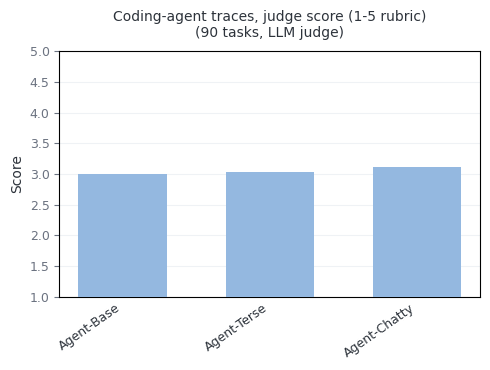

In [3]:
scores_by_agent = {a: df[df.agent == a]["score"].tolist() for a in AGENTS}

estats.plot_accuracy_bar(
    scores_by_agent,
    as_percent=False,
    score_range=(1, 5),
    title="Coding-agent traces, judge score (1-5 rubric)\n(90 tasks, LLM judge)",
)
plt.show()

To the eye, all three bars look essentially tied. Bummer. But, let's put real statistics behind it.

In [4]:
evaldata = estats.load_from(df, col_map={"agent": "model"})

naive = estats.compare_models(
    evaldata, metric="score", score_range=(1, 5), design="paired",
    omnibus=True, p_values=True, rng=np.random.default_rng(0),
)
naive.summary()

Shape: BenchmarkShape(models=1, prompts=3, input_vars=1, evaluators=1)
Models: 3 | Inputs: 90

--- Descriptive Statistics ---
                  mean  median       std        cv   iqr   cvar_10  p10   p25  p50  p75  p90
model                                                                                       
Agent-Chatty  3.111111     3.0  1.010556  0.324822  1.75  1.333333  2.0  2.25  3.0  4.0  4.0
Agent-Terse   3.033333     3.0  1.284742  0.423541  2.00  1.000000  1.0  2.00  3.0  4.0  5.0
Agent-Base    3.000000     3.0  1.101582  0.367194  2.00  1.000000  1.9  2.00  3.0  4.0  4.0

--- Mean Performance (marginal logit-t CIs) ---
  axis: [1.620, 4.447]  (· ±1σ, ░▒▓█ CI gradient [99%/95%/90%/68%], │ grand mean)
  Model          Interval Plot                                 Mean    CI Low   CI High
  Agent-Chatty          ··········░▒▓│███▓░··········        3.111    2.899    3.321
  Agent-Terse      ·············░▒▓██│██▓▒░·············     3.033    2.765    3.300
  Agent-Base        

The Friedman omnibus test can't reject "all three agents perform the same"
(p ≈ 0.84), and every pairwise comparison straddles zero. By the numbers on
screen, the three agents are statistically indistinguishable. 

A completely reasonable conclusion would be to ship whichever is cheapest to run, since
nothing here says one is actually better. But, as we will see, you'd be completely wrong.

### Before trusting that, check the judge

So far you've only seen judge scores: the table above was `item`, `agent`,
`score`, nothing else. Results from a real eval run, using an LLM judge. 
However, you should **always** have some ground truth labels. 
*How* you select the items for labeling matters, though, for judge-bias correction to work: 

**The labeled tasks have to be a random sample of the full item pool**.

Not the ones you found interesting, not the first 20 rows, or the ones the judge scored lowest. 
In statistics, this is called MCAR (missing completely at random).

To perform that random sampling, we can use the `evalstats label` CLI command against the csv of eval results that we previously fed into compare():

```bash
$ evalstats label eval_results.csv --factor agent --metric score --n-lab 20
```

`label` reads the file, auto-detects the paired design from the `item`/`agent`
columns, randomly marks 20 tasks per agent, and writes
`eval_results_for_labeling.csv`. This is the same data plus two new columns,
`_sampled_for_labeling` (boolean) and `human_score` (blank):

| item   | agent        | score | _sampled_for_labeling | human_score |
|--------|--------------|:-----:|:----------------------:|:-----------:|
| task03 | Agent-Base   |   3   | True                   |              |
| task03 | Agent-Terse  |   4   | True                   |              |
| task03 | Agent-Chatty |   3   | True                   |              |
| task11 | Agent-Base   |   2   | True                   |              |
| task11 | Agent-Terse  |   3   | True                   |              |
| task11 | Agent-Chatty |   2   | True                   |              |
| ...    | ...          |  ...  | ...                    |              |
| task00 | Agent-Base   |   3   | False                  |              |
| task00 | Agent-Terse  |   4   | False                  |              |
| task00 | Agent-Chatty |   3   | False                  |              |

Also by default, it moved every row marked for labeling to the top of the file, so a labeler
doesn't have to scroll to find the ones that need labeling (pass `--no-sort` to keep the original row order instead).

**Important.** Random sampling needs to be stratified by item, so that
ALL condition's outputs (model/prompt/agent whatever) for THAT ITEM are human-labeled.
In other words, if models A, B, C are being compared on a benchmark that includs items `i`, `j`, `k`,
and `i` is selected for labeling, then all three model outputs for `i` need labeling. 
`evalstats label` does this automatically for you.

Now, if you're a developer, you might fill in the spreadsheet yourself---
although this is dangerous, as you see the LLM scores and conditions and they might bias your opinion.
Instead, you should anonymize it so you only see the item-level info, the human score and sampled_for_labeling columns,
and ideally hand the file to a qualified expert or multiple experts to score.
Then, once you have those results, put them back in the spreadsheet that `evalstats` gave you,
in the human_score column, and run it through `judge_alignment` to check your LLM judge's alignment with the human labels: 

In [5]:
ar = estats.judge_alignment(
    evaldata, llm_metric="score", human_groundtruth="human_score",
    selection="random",
)
ar.summary()

Judge alignment report
──────────────────────────────────────────────────────────
Alignment set  : 60 of 270 items have human labels (22.2%)
Label selection: ✓ random
Note: corrections below assume the labeled subset is a random sample of the full item pool (MCAR). See 'Representativeness'.

✓ Representativeness: labeled items look like the full item pool

Alignment metrics (likert scores, labels are ordered categories, so metrics designed for ordinal data are used):
  Quadratic-weighted Cohen's κ   0.75  [ 0.63,  0.83]  substantial agreement
  Pearson r                      0.76  [ 0.63,  0.85]  large positive correlation
  Spearman r                     0.76  [ 0.61,  0.86]  large positive correlation
  ICC(2,1)                       0.75  [ 0.62,  0.83]  moderate absolute agreement

Per-condition alignment ('model'):
  Agent-Terse    Quadratic-weighted Cohen's κ = 0.82  (n=20)
  Agent-Chatty   Quadratic-weighted Cohen's κ = 0.75  (n=20)
  Agent-Base     Quadratic-weighted Cohen's κ 

The pooled IRR is still reassuring: quadratic-weighted
Cohen's κ of 0.75, "substantial agreement," and the representativeness check
confirms the 20 labeled tasks look like the full pool of 90. This is exactly
the kind of number that, reported alone in a paper or a dashboard, would read
as "the judge can be trusted." And even the per-model alignment is pretty good,
although Agent-Base is 0.65, it's still "substantial agreement." 

To run statistical inference, you simply pass that alignment result into `compare()`, which will
correctly fold the human-judge alignment into the comparison:

In [6]:
corrected = estats.compare_models(
    evaldata, metric="score", score_range=(1, 5), design="paired",
    omnibus=True, p_values=True, alignment={"score": ar},
    rng=np.random.default_rng(0),
)
corrected.summary()

Shape: BenchmarkShape(models=1, prompts=3, input_vars=1, evaluators=1)
Models: 3 | Inputs: 90

══════════════════════════════════════════════════════════
PPI-CORRECTED. Every estimate below relies on the judge_alignment(...) result passed via alignment=; see its .summary() for the full alignment report.
══════════════════════════════════════════════════════════

--- Descriptive Statistics ---
                  mean  median       std        cv   iqr   cvar_10  p10   p25  p50  p75  p90
model                                                                                       
Agent-Chatty  3.021486     3.0  1.010556  0.324822  1.75  1.333333  2.0  2.25  3.0  4.0  4.0
Agent-Terse   3.431921     3.0  1.284742  0.423541  2.00  1.000000  1.0  2.00  3.0  4.0  5.0
Agent-Base    2.999517     3.0  1.101582  0.367194  2.00  1.000000  1.9  2.00  3.0  4.0  4.0

--- Mean Performance (marginal bootstrap CIs) ---
  axis: [1.757, 4.858]  (· ±1σ, ░▒▓█ CI gradient [99%/95%/90%/68%], │ grand mean)
  Mode

The verdict flipped. Now, the PPI-Friedman omnibus
is significant (p ≈ 0.004), and Agent-Terse jumps to a clear lead: it
significantly beats both Agent-Chatty (p ≈ 0.026) and Agent-Base
(p ≈ 0.009). The judge is no less biased than it was a moment ago;
`evalstats` simply no longer needs it to be unbiased, since the labeled
sample tells the correction how it errs.

In case this seems like magic to you, you are not alone: initially, we were also skeptical. 
But PPI is well-established in the ML statistics literature. And we have run comprehensive Monte Carlo simulations
showing that the PPI-corrected estimates in `evalstats` are well-calibrated in Type I error while
still offering gains in statistical power to detect real effects, over the human-labeled subset alone.
We've also run simulations on real LLM judge and human rating data, via datasets like WMT,
where we randomly sample the human gold labels across thousands of simulations. PPI correction holds up in all of them. 

### Why this happened

`Agent-Terse` was engineered for this example to be the best of the three *and* to write the
shortest traces. The judge, as constructed, rewards length regardless of
actual quality, which is a known failure mode of real LLM judges. Look at how strongly each agent's judge score tracks its
trace length:

In [7]:
for agent in AGENTS:
    sub = df[df.agent == agent]
    corr = sub[["score", "length_z"]].corr().iloc[0, 1]
    print(f"{agent:14s}  mean length z-score {sub.length_z.mean():+.2f}   "
          f"corr(judge score, length) = {corr:.2f}")

Agent-Base      mean length z-score +0.40   corr(judge score, length) = 0.58
Agent-Terse     mean length z-score -0.37   corr(judge score, length) = 0.61
Agent-Chatty    mean length z-score +0.62   corr(judge score, length) = 0.47


The correlation between judge score and length sits between roughly 0.45 and
0.6 for every agent. The judge is quietly grading verbosity, not quality.
`Agent-Terse`'s short traces got marked down for the same reason its actual
quality should have marked it up, and the two effects landed close enough to
cancel in the naive comparison. 

Catching this unaided would mean suspecting it first, then probing for it: correlating scores against length, say. 
A developer may not have time to do that, and has no reason to suspect anything: the best agent simply looks unremarkable.

## How You Can Correct for Judge Bias

<img src="../media/smokey-bear-meme.png" alt="Smokey the Bear meme saying Only You Can Prevent Running Statistics over Raw LLM Judge Scores" style="max-width: 500px;" />

Nothing here required knowing the judge was biased in advance, guessing at
*how* it was biased, or manually correcting anything. The whole correction
came from:

1. **A randomly sampled set of human gold labels.** It doesn't need to be
   large (20 out of 90 tasks was enough here), but it does need to be a
   random sample of the full item pool, not a convenience sample or the
   easiest cases to grade. `evalstats`' representativeness check exists to
   catch it when it isn't.
2. **Passing `alignment=` to `compare()`.** Every CI, p-value, and omnibus
   test you already know how to read gets corrected automatically; there's
   no separate PPI API to learn, and nothing else about the code changes.

And critically: this wasn't conditional on the IRR number looking bad. It
looked *good* ("substantial agreement"), and the correction still reversed
the verdict. That's the point of the plot at the top of this page: a high
pooled agreement metric is not evidence that running statistics directly on
judge scores is safe. Apply the correction regardless of how good the IRR
looks, and let the CIs on the corrected estimate tell you whether the judge
ended up mattering.